In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [12]:
weight=0.7
bias=0.3

start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias

X[:5],y[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [15]:
train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]

len(X_train),len(X_test)

(40, 10)

In [21]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    
    plt.figure(figsize=(10,7))
    
    plt.scatter(train_data,train_labels,c="r",s=4,label="training data")
    
    plt.scatter(test_data,test_labels,c="b",s=4,label="testing data")
    
    if predictions is not None:
        plt.scatter(test_data,predictions,c='g',s=4,label="predictions")
        
    plt.legend(prop={"size":14})

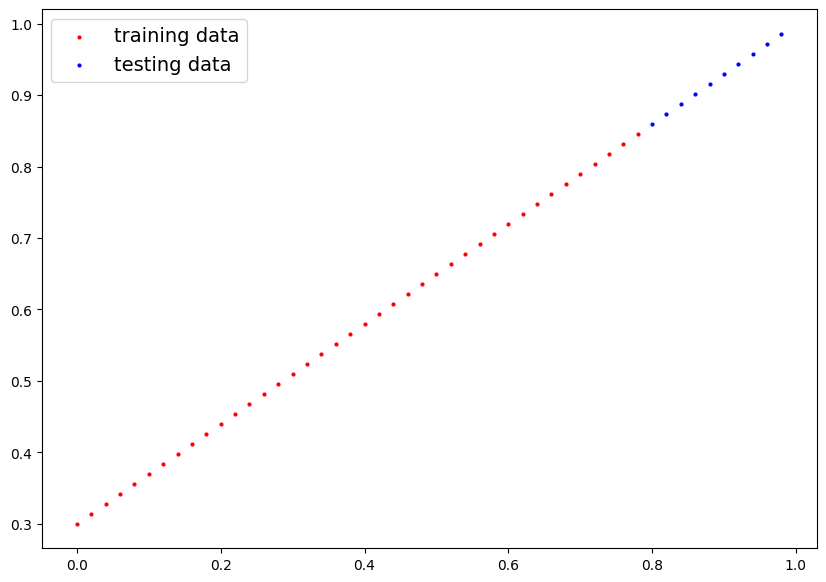

In [22]:
plot_predictions()

In [29]:
from torch import nn

class linearregression(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        
        self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        
    def forward(self,x:torch.tensor)->torch.tensor:
        return self.weight*x+self.bias

In [30]:
torch.manual_seed(42)

model_0=linearregression()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [31]:
with torch.inference_mode():
    y_pred=model_0(X_test)

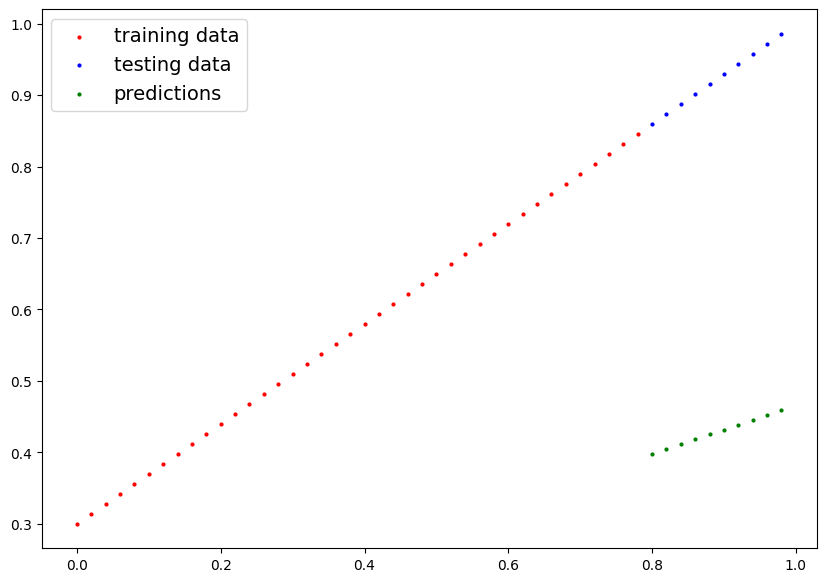

In [32]:
plot_predictions(predictions=y_pred)

In [33]:
loss_fn=nn.L1Loss()

optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)

In [38]:
epochs=10

for epoch in range(epochs):
    model_0.train()
    
    y_pred=model_0(X_train)
    
    loss=loss_fn(y_pred,y_train)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    model_0.eval()
    
    print(model_0.state_dict())

OrderedDict({'weight': tensor([0.6122]), 'bias': tensor([0.2588])})
OrderedDict({'weight': tensor([0.6512]), 'bias': tensor([0.3588])})
OrderedDict({'weight': tensor([0.6122]), 'bias': tensor([0.2588])})
OrderedDict({'weight': tensor([0.6512]), 'bias': tensor([0.3588])})
OrderedDict({'weight': tensor([0.6122]), 'bias': tensor([0.2588])})
OrderedDict({'weight': tensor([0.6512]), 'bias': tensor([0.3588])})
OrderedDict({'weight': tensor([0.6122]), 'bias': tensor([0.2588])})
OrderedDict({'weight': tensor([0.6512]), 'bias': tensor([0.3588])})
OrderedDict({'weight': tensor([0.6122]), 'bias': tensor([0.2588])})
OrderedDict({'weight': tensor([0.6512]), 'bias': tensor([0.3588])})


In [39]:
with torch.inference_mode():
    y_preds_new=model_0(X_test)

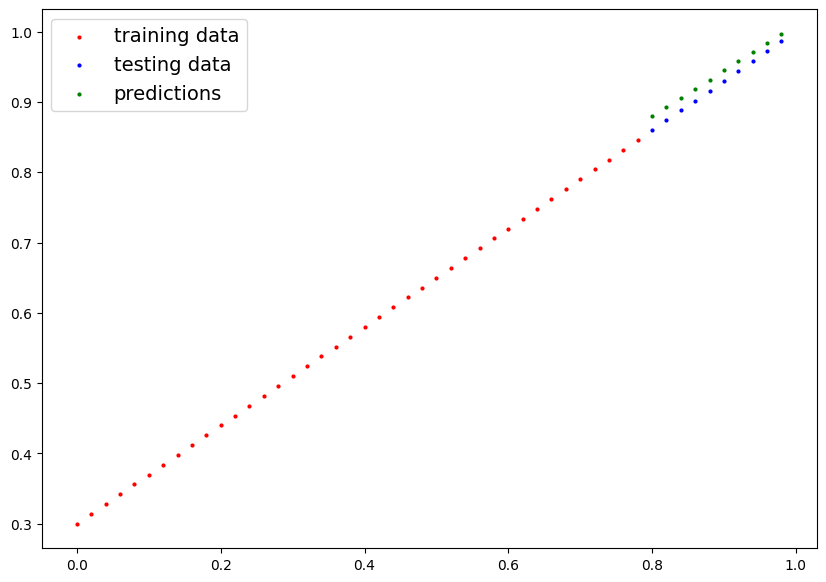

In [40]:
plot_predictions(predictions=y_preds_new)

In [42]:
torch.manual_seed(42)
epochs=200

for epoch in range(epochs):
    model_0.train()
    
    y_pred=model_0(X_train)
    
    loss=loss_fn(y_pred,y_train)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    model_0.eval()
    with torch.inference_mode():
        test=model_0(X_test)
        
        test_loss=loss_fn(test,y_test)
    if epoch%20==0:
        print(f"epoch :{epoch} | loss:{loss} | test loss:{test_loss}")
    

epoch :0 | loss:0.07543627172708511 | test loss:0.01536894403398037
epoch :20 | loss:0.07543627172708511 | test loss:0.01536894403398037
epoch :40 | loss:0.07543627172708511 | test loss:0.01536894403398037
epoch :60 | loss:0.07543627172708511 | test loss:0.01536894403398037
epoch :80 | loss:0.07543627172708511 | test loss:0.01536894403398037
epoch :100 | loss:0.07543627172708511 | test loss:0.01536894403398037
epoch :120 | loss:0.07543627172708511 | test loss:0.01536894403398037
epoch :140 | loss:0.07543627172708511 | test loss:0.01536894403398037
epoch :160 | loss:0.07543627172708511 | test loss:0.01536894403398037
epoch :180 | loss:0.07543627172708511 | test loss:0.01536894403398037
